## ME2202 : Heat and Mass Transfer - Project 1 (Case 1)

#### Group Members : 
##### 2302MT03 Shourya
##### 2303ME02 Abhimanyu
##### 2303ME08 Pradyumna
##### 2303ME10 Suryashraj
##### 2303ME14 Saikumar

### Steady-state heat conduction in a square plate

### Develop a code in Matlab/Python to solve the steady-conduction in a rectangular plate of  1m x 1 m size having thermal conductivity of 10 W/m-K using finite difference method for the following : Case-1: The left, bottom and right faces are maintained at 100 C and the top face at 500 C. Compare the nodal solution with the	analytical infinite series solution. Draw the isothermal contours on the plate.

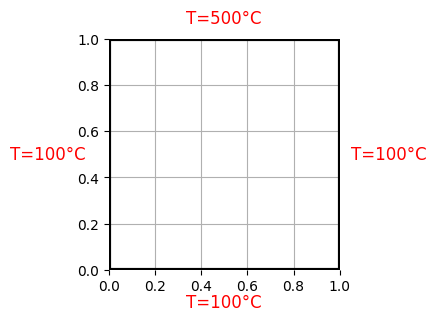

Enter Number of Nodal points in x (or y) direction (dx = dy)(>=4) :  20


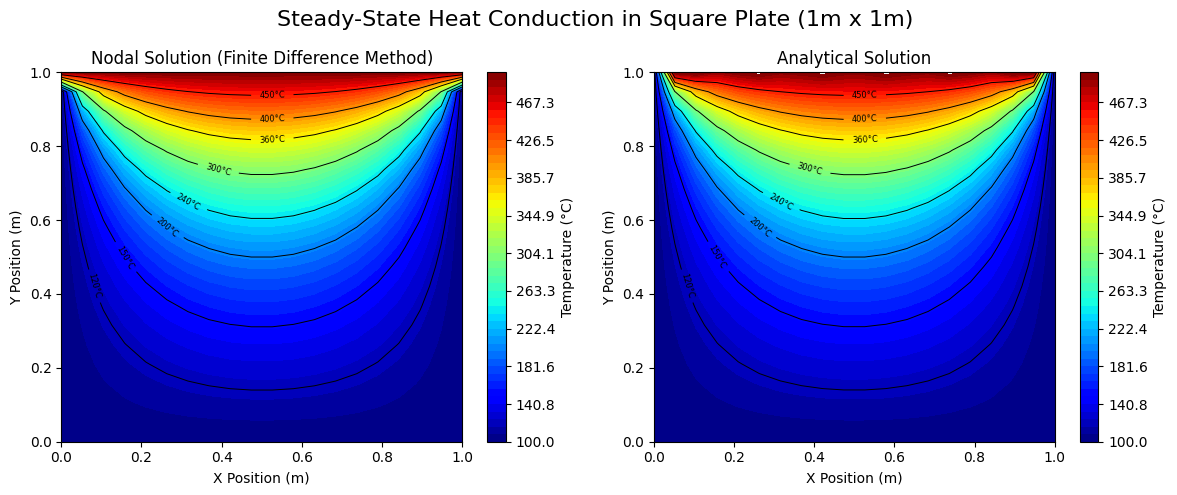

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(3, 3))

# Define Square Coordinates (1m x 1m)
square = [[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]

# Plot the square
ax.plot(*zip(*square), 'k', linewidth=3)

# Labelling Boundary Temperatures
ax.text(-0.1, 0.5, "T=100°C", va='center', ha='right', fontsize=12, color='red')
ax.text(1.05, 0.5, "T=100°C", va='center', ha='left', fontsize=12, color='red')
ax.text(0.5, 1.05, "T=500°C", va='bottom', ha='center', fontsize=12, color='red')
ax.text(0.5, -0.1, "T=100°C", va='top', ha='center', fontsize=12, color='red')

# Adjust plot settings
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_frame_on(False)
plt.grid()
# Show the plot
plt.show()

# Solving the problem : 

# Define plate dimensions and grid resolution
L, W = 1.0, 1.0  # Length and Width of plate (m)
nx = int(input("Enter Number of Nodal points in x (or y) direction (dx = dy)(>=4) : "))  # Number of grid points in x and y directions
ny = nx
dx, dy = L / (nx - 1), W / (ny - 1)  # Grid spacing
thermal_conductivity = 10 # Not required for steady-state case

# Initialize Temperature Field
T_nodal = np.zeros((ny, nx))

# Applying boundary conditions
T_nodal[0, :] = 100   # Bottom boundary (100°C)
T_nodal[:, 0] = 100   # Left boundary (100°C)
T_nodal[:, -1] = 100  # Right boundary (100°C)
T_nodal[-1, :] = 500  # Top boundary (500°C)

# Solver parameters
tolerance = 1e-4  # Convergence criteria
max_iterations = 5000  # Maximum iterations

# Solve using Gauss-Seidel iteration
for iteration in range(max_iterations):
    T_old = T_nodal.copy()
    
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            T_nodal[i, j] = 0.25 * (T_old[i+1, j] + T_old[i-1, j] + T_old[i, j+1] + T_old[i, j-1])
    
    if np.max(np.abs(T_nodal - T_old)) < tolerance:
        break

# Define analytical solution function
def T_analytical_solution(x, y, W=1.0, L=1.0, num_terms=50, T1=100, T2=500):
    T = 0
    for n in range(1, num_terms+1):
        term = ((-1)**(n+1) + 1) / n
        T += (2 / np.pi) * term * np.sin(n * np.pi * x / W) * (np.sinh(n * np.pi * y / W) / np.sinh(n * np.pi * L / W))
    return T1 + (T2 - T1) * T

# Compute analytical solution
x_vals = np.linspace(0, W, nx)
y_vals = np.linspace(0, L, ny)
T_analytical = np.array([[T_analytical_solution(x, y) for x in x_vals] for y in y_vals])

# Define contour levels
contour_levels = np.linspace(100, 500, 50)
# Contour Lines for comparison in both Solutions
level_lines = [120, 150, 200, 240, 300, 360, 400, 450]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Steady-State Heat Conduction in Square Plate (1m x 1m)', fontsize=16)
# Plot nodal solution
ax = axes[0]
contour_nodal = ax.contourf(x_vals, y_vals, T_nodal, cmap="jet", levels=contour_levels, vmin=100, vmax=500)
fig.colorbar(contour_nodal, ax=ax, label="Temperature (°C)")
contour_lines = ax.contour(x_vals, y_vals, T_nodal, colors='black', linewidths=0.7, levels=level_lines)
ax.clabel(contour_lines, inline=True, fontsize=6, fmt='%1.0f°C')
ax.set(title="Nodal Solution (Finite Difference Method)", xlabel="X Position (m)", ylabel="Y Position (m)")

# Plot analytical solution
ax = axes[1]
contour_analytical = ax.contourf(x_vals, y_vals, T_analytical, cmap="jet", levels=contour_levels, vmin=100, vmax=500)
fig.colorbar(contour_analytical, ax=ax, label="Temperature (°C)")
contour_lines = ax.contour(x_vals, y_vals, T_analytical, colors='black', linewidths=0.7, levels=level_lines)
ax.clabel(contour_lines, inline=True, fontsize=6, fmt='%1.0f°C')
ax.set(title="Analytical Solution", xlabel="X Position (m)", ylabel="Y Position (m)")

# Adjust layout and display plot
plt.tight_layout()
plt.show()